In [25]:
%matplotlib inline
import os
import json

experiment_dir = "../stats/exp-2024-12-09_12-18-26-verify"
json_files = [f for f in os.listdir(experiment_dir + "/json") if f.endswith(".json")]

experiment_data: list[dict] = []
for json_file in json_files:
    with open(os.path.join(experiment_dir + "/json/", json_file), "r") as f:
        data: dict = json.load(f)
        if "error" in data["result"]:
            print(f"Error in {json_file}: {data['result']['error']}")
            continue
        experiment_data.append(data)

print(f"Loaded {len(experiment_data)} JSON files from {experiment_dir}")
experiment_data.sort(
    key=lambda x: (x["experiment"]["name"], str(x["experiment"]["variant"]))
)
longest_experiment = max(experiment_data, key=lambda x: x["time"]["total"])
print(
    f"Longest experiment {longest_experiment['experiment']['name']} {longest_experiment['experiment']['variant']} took {longest_experiment['time']['total']:.2f} s ({longest_experiment['time']['total'] / (60 * 60):.2f} h)."
)

Loaded 9 JSON files from ../stats/exp-2024-12-09_12-18-26-verify
Longest experiment compare_paynt_strat [0, 0] took 3210.14 s (0.89 h).


In [26]:
import matplotlib.pyplot as plt

symbols = [
    "o",
    "s",
    "D",
    "^",
    "v",
    "<",
    ">",
    "p",
    "*",
    "h",
    "H",
    "+",
    "x",
    "d",
    "|",
    "_",
    ".",
    "1",
]
colors = plt.get_cmap("tab20")

experiment_names = set(data["experiment"]["name"] for data in experiment_data)
experiment_symbols = {
    name: symbols[i % len(symbols)] for i, name in enumerate(experiment_names)
}

for i, exp in enumerate(experiment_data):
    exp["symbol"] = experiment_symbols[exp["experiment"]["name"]]
    exp["color"] = colors(i % colors.N)

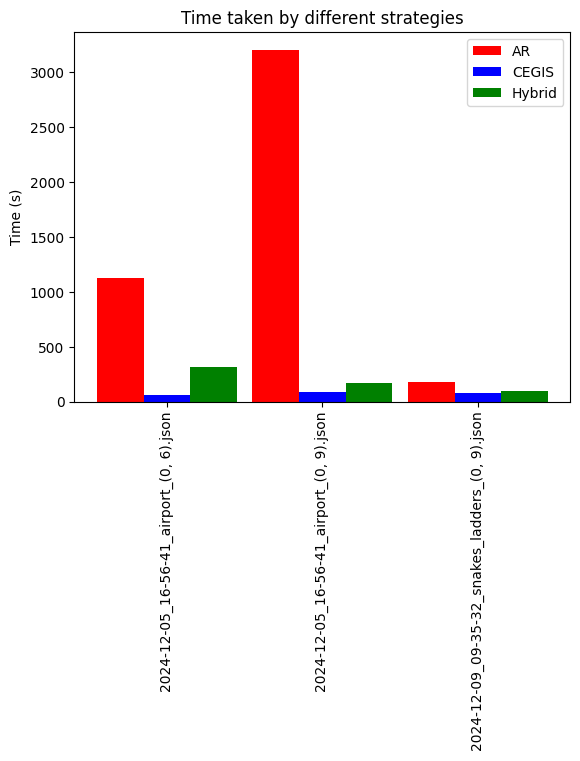

In [27]:
name_index = {
    name: i
    for i, name in enumerate(
        sorted(
            set(
                [
                    data["experiment"]["results_file"].split("/")[-1]
                    for data in experiment_data
                ]
            )
        )
    )
}

ar_strategy_times = [
    (data["experiment"]["results_file"].split("/")[-1], data["result"]["paynt_time"])
    for data in experiment_data
    if data["experiment"]["paynt_strategy"] == "ar"
]

cegis_strategy_times = [
    (data["experiment"]["results_file"].split("/")[-1], data["result"]["paynt_time"])
    for data in experiment_data
    if data["experiment"]["paynt_strategy"] == "cegis"
]

hybrid_strategy_times = [
    (data["experiment"]["results_file"].split("/")[-1], data["result"]["paynt_time"])
    for data in experiment_data
    if data["experiment"]["paynt_strategy"] == "hybrid"
]

bar_width = 0.3
plt.bar(
    [name_index[x[0]] for x in ar_strategy_times],
    [x[1] for x in ar_strategy_times],
    bar_width,
    color="r",
    label="AR",
)
plt.bar(
    [name_index[x[0]] + bar_width for x in cegis_strategy_times],
    [x[1] for x in cegis_strategy_times],
    bar_width,
    color="b",
    label="CEGIS",
)
plt.bar(
    [name_index[x[0]] + 2 * bar_width for x in hybrid_strategy_times],
    [x[1] for x in hybrid_strategy_times],
    bar_width,
    color="g",
    label="Hybrid",
)

plt.xticks(
    [name_index[x] + bar_width for x in name_index],
    list(name_index.keys()),
    rotation=90,
)
plt.ylabel("Time (s)")
plt.legend()
plt.title("Time taken by different strategies")
plt.show()

In [28]:
from collections import defaultdict

thresholds_by_file = defaultdict(set)

for exp in experiment_data:
    results_file = exp["experiment"]["results_file"]
    threshold = exp["result"].get("goal_threshold")
    if threshold is not None:
        thresholds_by_file[results_file].add(threshold)

# Check for discrepancies
discrepancies = {
    file: thresholds
    for file, thresholds in thresholds_by_file.items()
    if len(thresholds) > 1
}

if discrepancies:
    print("Discrepancies found in the following files:")
    for file, thresholds in discrepancies.items():
        print(f"{file}: {thresholds}")
else:
    print("No discrepancies found.")

Discrepancies found in the following files:
stats/exp-2024-12-05_16-56-41/json/2024-12-05_16-56-41_airport_(0, 9).json: {0.2434441804038328, 0.2819370622193146, 0.12924033005553104}
stats/exp-2024-12-09_09-35-32-snl/json/2024-12-09_09-35-32_snakes_ladders_(0, 9).json: {0.148148148124989, 0.08333333333210179}
stats/exp-2024-12-05_16-56-41/json/2024-12-05_16-56-41_airport_(0, 6).json: {0.20841200299108156, 0.26011635469149297, 0.1406512241364957}
